# 01 — Primary Experiment: Baseline Predictive Multiplicity

## 1. Purpose and scope

This notebook establishes:
- **Baseline predictive multiplicity** across datasets and runs (global Rashomon selection, K=25)
- **Baseline spatial clustering** of multiplicity (Moran's I, LISA HH/LL)
- **Core metrics** that define the later analysis

**Explicitly out of scope (handled elsewhere):**
- Family-specific comparisons → dedicated family/hyperparameter notebook
- Robustness analyses (K, kNN, calibration, conflict-threshold, etc.) → notebooks 02–07, 10
- Interpretability and rules → notebook 09

## 2. Setup

In [21]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from analysis.experiment_runner import run_dataset_experiment, run_all_experiments
from analysis.run_analysis import load_P_test, select_rashomon_global, run_multiplicity, run_spatial
from analysis.preprocessing import get_transformed_test_features

RESULTS_DIR = ROOT / "results"
DATASETS = ["compas", "german", "breast_cancer"]
K = 25
K_NN = 30
SEED = 42
SUPPORTED_DATASETS = ["compas", "german", "breast_cancer"]
DATASET = None  # set to e.g. "compas" to run one dataset only

In [22]:
# Load results: run experiment for each dataset
if DATASET:
    dataset_dir = RESULTS_DIR / DATASET
    agg_df = run_dataset_experiment(dataset_dir, dataset_name=DATASET, verbose=True)
else:
    agg_df = run_all_experiments(RESULTS_DIR, datasets=SUPPORTED_DATASETS, verbose=True)

agg_df

Dataset: compas
  Run 1/10: seed=0
  Run 2/10: seed=1
  Run 3/10: seed=2
  Run 4/10: seed=3
  Run 5/10: seed=4
  Run 6/10: seed=5
  Run 7/10: seed=6
  Run 8/10: seed=7
  Run 9/10: seed=8
  Run 10/10: seed=9
Dataset: german
  Run 1/10: seed=0
  Run 2/10: seed=1
  Run 3/10: seed=2
  Run 4/10: seed=3
  Run 5/10: seed=4
  Run 6/10: seed=5
  Run 7/10: seed=6
  Run 8/10: seed=7
  Run 9/10: seed=8
  Run 10/10: seed=9
Dataset: breast_cancer
  Run 1/10: seed=0
  Run 2/10: seed=1
  Run 3/10: seed=2
  Run 4/10: seed=3
  Run 5/10: seed=4
  Run 6/10: seed=5
  Run 7/10: seed=6
  Run 8/10: seed=7
  Run 9/10: seed=8
  Run 10/10: seed=9


,dataset,n_runs,mean_variance_mean,mean_variance_std,mean_conflict_mean,mean_conflict_std,frac_conflict_gt0_mean,frac_conflict_ge025_mean,moran_i_mean,moran_i_std,...,frac_significant_hh,null_mean,null_std,null_n_hh_mean,acc_mean_mean,acc_mean_std,brier_mean_mean,brier_mean_std,acc_ensemble_mean,brier_ensemble_mean
0,compas,10,0.001308,0.000306,0.035440,0.006968,0.179487,0.059113,0.199279,0.077227,...,1.0,-0.000338,0.006227,0.000,0.679640,0.008010,0.209185,0.003780,0.682121,0.207877
1,german,10,0.005023,0.002129,0.059280,0.021920,0.300500,0.098500,0.104155,0.039695,...,0.7,-0.005481,0.014562,0.000,0.749080,0.027601,0.170269,0.015416,0.757000,0.165245
2,breast_cancer,10,0.003182,0.002649,0.011544,0.008383,0.054386,0.019298,0.031547,0.020719,...,0.3,-0.008812,0.017503,0.156,0.973158,0.007858,0.021752,0.006468,0.977193,0.018571


### Audit: shape checks and compact summary

Verify data shapes and produce a compact summary table for reproducibility.

In [23]:
# Audit-friendly shape checks
def load_per_run_summary(results_dir: Path, dataset: str) -> pd.DataFrame:
    path = results_dir / dataset / "summary_per_run.csv"
    if not path.exists():
        return pd.DataFrame()
    return pd.read_csv(path)

# Shape checks
print("=== Audit: shape checks ===")
print(f"agg_df shape: {agg_df.shape}")
for ds in agg_df["dataset"].unique():
    pr = load_per_run_summary(RESULTS_DIR, ds)
    if not pr.empty:
        print(f"  {ds} per_run: {pr.shape}")
# Core object shapes (one representative run: compas seed=0)
_run_dir = RESULTS_DIR / "compas" / "seed=0"
if _run_dir.exists():
    _P_test = load_P_test(_run_dir)
    _idx = select_rashomon_global(_run_dir, K=K)
    _P_sel = _P_test[_idx]
    _mult = run_multiplicity(_run_dir, K=K)
    _X = get_transformed_test_features(_run_dir, "compas")
    _sp = run_spatial(_run_dir, _X, K=K, k=K_NN, seed=SEED)
    print(f"  P_test: {_P_test.shape}, P_sel: {_P_sel.shape}")
    print(f"  var_p: {_mult['pointwise_variance'].shape}, conflict: {_mult['pointwise_conflict'].shape}")
    print(f"  HH_mask: {_sp['HH_mask'].shape}, LL_mask: {_sp['LL_mask'].shape}")

# Compact summary table (all baseline metrics for audit)
summary_cols = ["dataset", "n_runs", "acc_mean_mean", "brier_mean_mean", "acc_ensemble_mean", "brier_ensemble_mean",
                "mean_variance_mean", "mean_variance_std", "ambiguity_mean", "ambiguity_std",
                "disagreement_rate_mean", "disagreement_rate_std", "discrepancy_mean", "discrepancy_std",
                "mean_conflict_mean", "mean_conflict_std", "frac_conflict_gt0_mean", "frac_conflict_ge025_mean",
                "moran_i_mean", "moran_i_std", "n_hh_mean", "n_ll_mean",
                "conflict_moran_i_mean", "conflict_n_hh_mean", "conflict_n_ll_mean",
                "neighborhood_agreement_mean", "lcae_mean", "hh_jaccard_var_conflict_mean"]
display_cols = [c for c in summary_cols if c in agg_df.columns]
audit_table = agg_df[display_cols].round(6)
print("\n=== Compact summary table ===")
audit_table

=== Audit: shape checks ===
agg_df shape: (3, 31)
  compas per_run: (10, 25)
  german per_run: (10, 25)
  breast_cancer per_run: (10, 25)
  P_test: (250, 1443), P_sel: (25, 1443)
  var_p: (1443,), conflict: (1443,)
  HH_mask: (1443,), LL_mask: (1443,)

=== Compact summary table ===


,dataset,n_runs,acc_mean_mean,brier_mean_mean,acc_ensemble_mean,brier_ensemble_mean,mean_variance_mean,mean_variance_std,mean_conflict_mean,mean_conflict_std,...,frac_conflict_ge025_mean,moran_i_mean,moran_i_std,n_hh_mean,n_ll_mean,conflict_moran_i_mean,conflict_n_hh_mean,neighborhood_agreement_mean,lcae_mean,hh_jaccard_var_conflict_mean
0,compas,10,0.679640,0.209185,0.682121,0.207877,0.001308,0.000306,0.035440,0.006968,...,0.059113,0.199279,0.077227,86.7,553.8,0.171769,107.9,0.849272,0.001139,0.055326
1,german,10,0.749080,0.170269,0.757000,0.165245,0.005023,0.002129,0.059280,0.021920,...,0.098500,0.104155,0.039695,2.7,36.9,0.052491,0.5,0.744583,0.004290,0.214286
2,breast_cancer,10,0.973158,0.021752,0.977193,0.018571,0.003182,0.002649,0.011544,0.008383,...,0.019298,0.031547,0.020719,1.6,14.0,0.016281,0.4,0.875760,0.002498,0.600000


## 3. Global Rashomon baseline metrics

**Metric definitions (from analysis.run_analysis):**
- *mean_variance*: mean over points of Var_m(p_hat_m)
- *ambiguity*: probability-space ambiguity (Rudin et al.)
- *disagreement_rate*: fraction of point pairs with |p_i - p_j| > epsilon
- *discrepancy*: max over point pairs of |p_i - p_j|
- *mean_conflict*: mean of pointwise conflict (hard-vote disagreement)
- *frac_conflict_gt0*, *frac_conflict_ge025*: fraction of points with conflict > 0 or >= 0.25

Performance: acc_mean, brier_mean (mean over Rashomon models), acc_ensemble, brier_ensemble.

In [24]:
# Baseline metrics table (formatted mean ± std)
def format_mean_std(mean_val: float, std_val: float, decimals: int = 4) -> str:
    return f"{mean_val:.{decimals}f} ± {std_val:.{decimals}f}"

summary_display = agg_df[["dataset", "n_runs"]].copy()
if "mean_variance_mean" in agg_df.columns:
    summary_display["mean_variance"] = agg_df.apply(
        lambda r: format_mean_std(r["mean_variance_mean"], r["mean_variance_std"]), axis=1
    )
if "mean_conflict_mean" in agg_df.columns:
    summary_display["mean_conflict"] = agg_df.apply(
        lambda r: format_mean_std(r["mean_conflict_mean"], r["mean_conflict_std"]), axis=1
    )
if "moran_i_mean" in agg_df.columns:
    summary_display["moran_i"] = agg_df.apply(
        lambda r: format_mean_std(r["moran_i_mean"], r["moran_i_std"]), axis=1
    )
summary_display

,dataset,n_runs,mean_variance,mean_conflict,moran_i
0,compas,10,0.0013 ± 0.0003,0.0354 ± 0.0070,0.1993 ± 0.0772
1,german,10,0.0050 ± 0.0021,0.0593 ± 0.0219,0.1042 ± 0.0397
2,breast_cancer,10,0.0032 ± 0.0026,0.0115 ± 0.0084,0.0315 ± 0.0207


**Interpretation:** Mean variance and conflict quantify predictive multiplicity.
Higher values indicate more disagreement among Rashomon models. German Credit typically
shows higher mean variance than COMPAS or Breast Cancer.

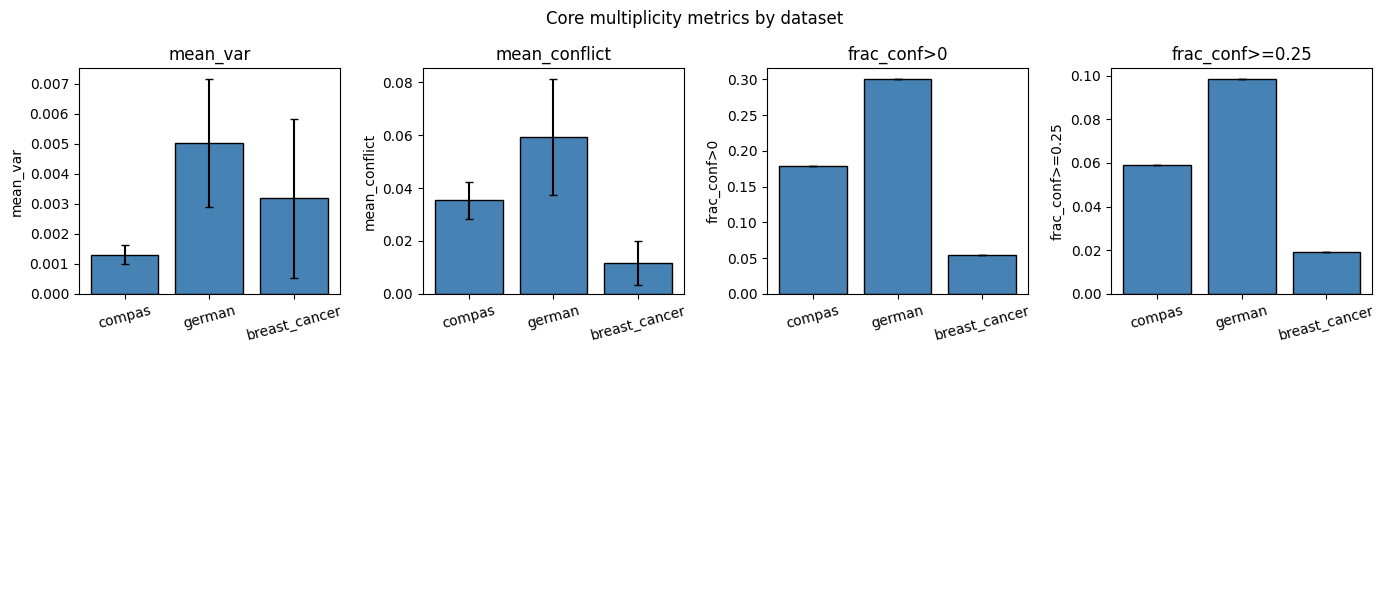

In [25]:
# Bar chart: core scalar metrics by dataset (compact multiplicity summary)
metric_cols = ["mean_variance_mean", "ambiguity_mean", "disagreement_rate_mean", "discrepancy_mean",
               "mean_conflict_mean", "frac_conflict_gt0_mean", "frac_conflict_ge025_mean"]
metric_labels = ["mean_var", "ambiguity", "disagree_rate", "discrepancy", "mean_conflict", "frac_conf>0", "frac_conf>=0.25"]
available = [(m, l) for m, l in zip(metric_cols, metric_labels) if m in agg_df.columns]
if available:
    n_metrics = len(available)
    fig, axes = plt.subplots(2, 4, figsize=(14, 6))
    axes = axes.flatten()
    for i, (col, label) in enumerate(available):
        if i < len(axes):
            x = np.arange(len(agg_df))
            err = agg_df[col.replace("_mean", "_std")] if col.replace("_mean", "_std") in agg_df.columns else 0
            axes[i].bar(x, agg_df[col], yerr=err, capsize=3, color="steelblue", edgecolor="black")
            axes[i].set_xticks(x)
            axes[i].set_xticklabels(agg_df["dataset"].values, rotation=15)
            axes[i].set_ylabel(label)
            axes[i].set_title(label)
    for j in range(len(available), len(axes)):
        axes[j].axis("off")
    plt.suptitle("Core multiplicity metrics by dataset", fontsize=12)
    plt.tight_layout()
    plt.show()

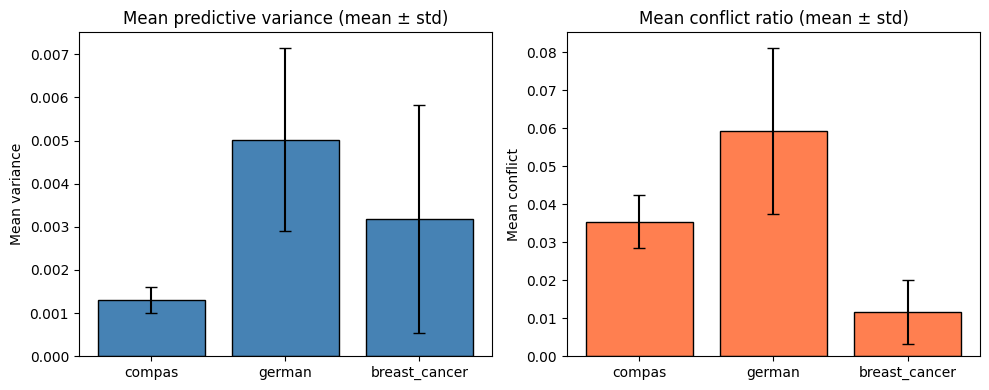

In [26]:
# Bar charts: mean variance and mean conflict
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
x = np.arange(len(agg_df))
labels = agg_df["dataset"].values

axes[0].bar(x, agg_df["mean_variance_mean"], yerr=agg_df["mean_variance_std"],
            capsize=4, color="steelblue", edgecolor="black")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel("Mean variance")
axes[0].set_title("Mean predictive variance (mean ± std)")

axes[1].bar(x, agg_df["mean_conflict_mean"], yerr=agg_df["mean_conflict_std"],
            capsize=4, color="coral", edgecolor="black")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_ylabel("Mean conflict")
axes[1].set_title("Mean conflict ratio (mean ± std)")
plt.tight_layout()
plt.show()

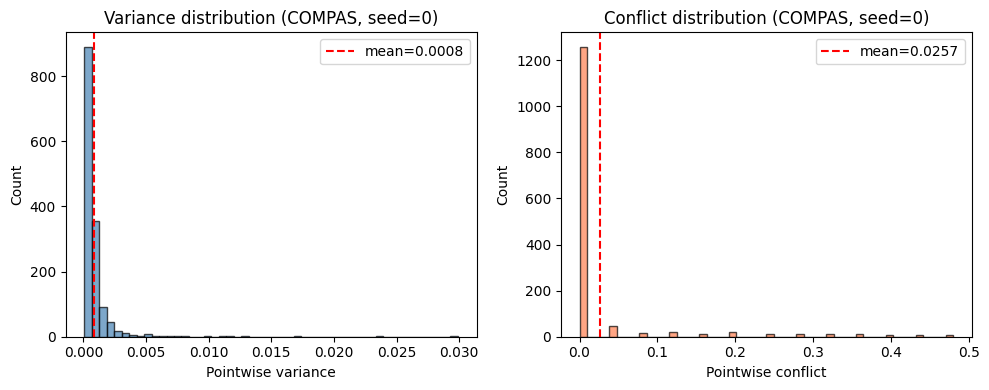

In [27]:
# Variance and conflict distributions (representative run: compas seed=0)
run_dir = RESULTS_DIR / "compas" / "seed=0"
P_test = load_P_test(run_dir)
idx = select_rashomon_global(run_dir, K=K)
mult = run_multiplicity(run_dir, K=K)
var_p = mult["pointwise_variance"]
conflict = mult["pointwise_conflict"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(var_p, bins=50, color="steelblue", edgecolor="black", alpha=0.7)
axes[0].axvline(var_p.mean(), color="red", linestyle="--", label=f"mean={var_p.mean():.4f}")
axes[0].set_xlabel("Pointwise variance")
axes[0].set_ylabel("Count")
axes[0].set_title("Variance distribution (COMPAS, seed=0)")
axes[0].legend()

axes[1].hist(conflict, bins=50, color="coral", edgecolor="black", alpha=0.7)
axes[1].axvline(conflict.mean(), color="red", linestyle="--", label=f"mean={conflict.mean():.4f}")
axes[1].set_xlabel("Pointwise conflict")
axes[1].set_ylabel("Count")
axes[1].set_title("Conflict distribution (COMPAS, seed=0)")
axes[1].legend()
plt.tight_layout()
plt.show()

## 4. Baseline spatial metrics

Moran's I (global spatial autocorrelation of variance), LISA counts (HH hotspots, LL coldspots),
neighborhood agreement, LCAE.

*Detailed significance, stability, calibration, and sensitivity analyses are handled in notebooks 02–07 and 10.*

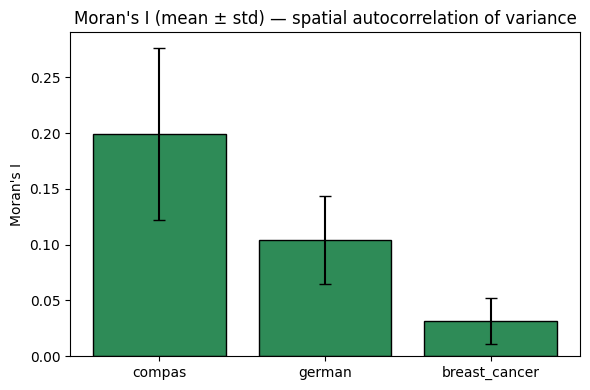

In [28]:
# Moran's I bar chart
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(agg_df))
ax.bar(x, agg_df["moran_i_mean"], yerr=agg_df["moran_i_std"],
       capsize=4, color="seagreen", edgecolor="black")
ax.set_xticks(x)
ax.set_xticklabels(agg_df["dataset"].values)
ax.set_ylabel("Moran's I")
ax.set_title("Moran's I (mean ± std) — spatial autocorrelation of variance")
plt.tight_layout()
plt.show()

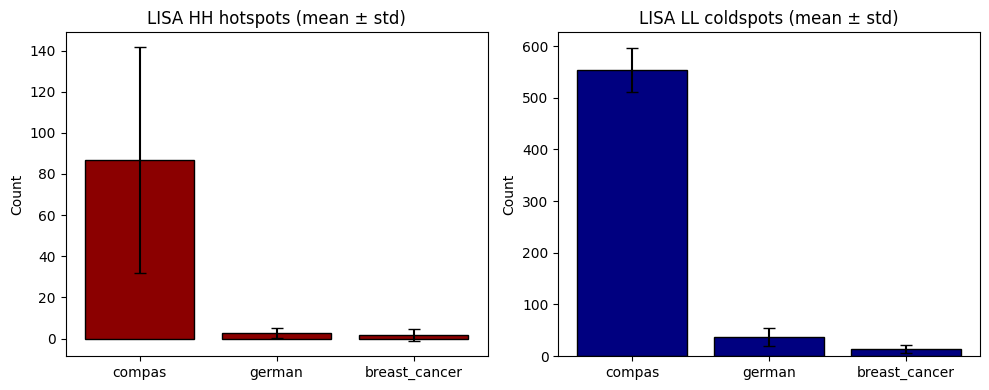

In [29]:
# LISA counts (HH, LL) bar chart — from per-run data
lisa_rows = []
for ds in agg_df["dataset"].unique():
    pr = load_per_run_summary(RESULTS_DIR, ds)
    if pr.empty:
        continue
    lisa_rows.append({
        "dataset": ds,
        "n_hh_mean": pr["n_hh"].mean(),
        "n_hh_std": pr["n_hh"].std() if len(pr) > 1 else 0,
        "n_ll_mean": pr["n_ll"].mean(),
        "n_ll_std": pr["n_ll"].std() if len(pr) > 1 else 0,
    })
lisa_df = pd.DataFrame(lisa_rows)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
x = np.arange(len(lisa_df))
labels = lisa_df["dataset"].values

axes[0].bar(x, lisa_df["n_hh_mean"], yerr=lisa_df["n_hh_std"],
            capsize=4, color="darkred", edgecolor="black")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel("Count")
axes[0].set_title("LISA HH hotspots (mean ± std)")

axes[1].bar(x, lisa_df["n_ll_mean"], yerr=lisa_df["n_ll_std"],
            capsize=4, color="navy", edgecolor="black")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_ylabel("Count")
axes[1].set_title("LISA LL coldspots (mean ± std)")
plt.tight_layout()
plt.show()

**Interpretation:** Moran's I > 0 indicates positive spatial autocorrelation:
high-variance points tend to cluster. HH hotspots are regions where high variance
co-occurs with high-variance neighbors. COMPAS typically shows the strongest
spatial structure.

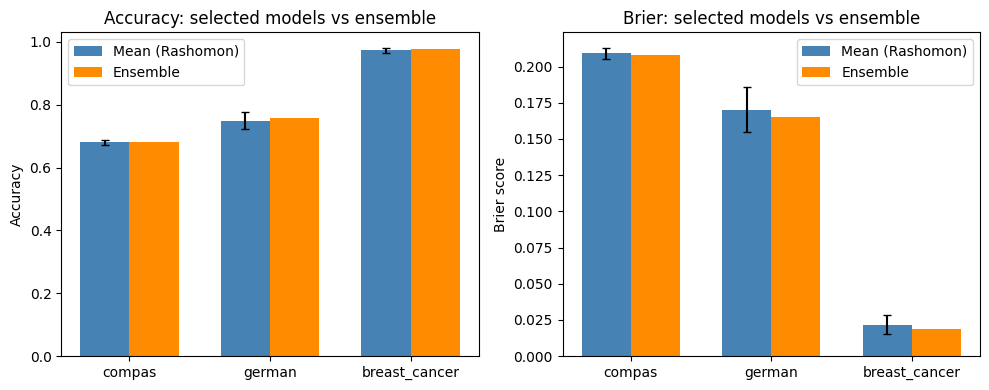

In [30]:
# Performance comparison: selected models vs ensemble (near-optimal check)
if "acc_mean_mean" in agg_df.columns and "acc_ensemble_mean" in agg_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    x = np.arange(len(agg_df))
    w = 0.35
    labels = agg_df["dataset"].values

    axes[0].bar(x - w/2, agg_df["acc_mean_mean"], w, yerr=agg_df["acc_mean_std"],
                capsize=3, label="Mean (Rashomon)", color="steelblue")
    axes[0].bar(x + w/2, agg_df["acc_ensemble_mean"], w, label="Ensemble", color="darkorange")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels)
    axes[0].set_ylabel("Accuracy")
    axes[0].set_title("Accuracy: selected models vs ensemble")
    axes[0].legend()

    axes[1].bar(x - w/2, agg_df["brier_mean_mean"], w, yerr=agg_df["brier_mean_std"],
                capsize=3, label="Mean (Rashomon)", color="steelblue")
    axes[1].bar(x + w/2, agg_df["brier_ensemble_mean"], w, label="Ensemble", color="darkorange")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels)
    axes[1].set_ylabel("Brier score")
    axes[1].set_title("Brier: selected models vs ensemble")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

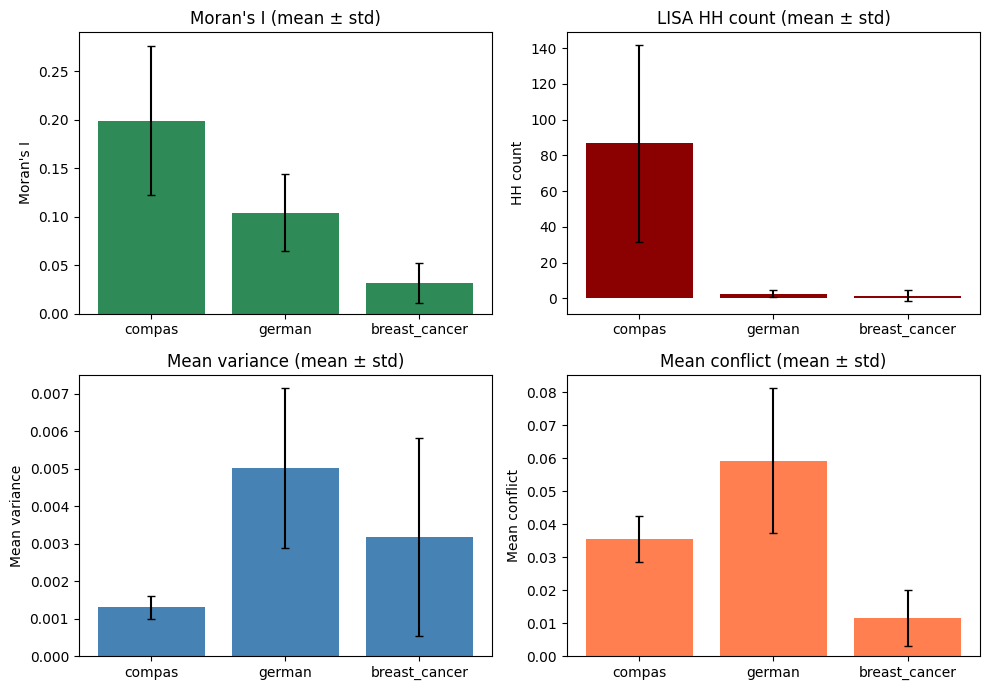

In [31]:
# Dataset comparison: 2x2 bar charts (Moran's I, HH count, mean variance, mean conflict)
comp_rows = []
for ds in agg_df["dataset"].unique():
    pr = load_per_run_summary(RESULTS_DIR, ds)
    if pr.empty:
        continue
    comp_rows.append({
        "dataset": ds,
        "moran_i_mean": pr["moran_i"].mean(),
        "moran_i_std": pr["moran_i"].std() if len(pr) > 1 else 0,
        "n_hh_mean": pr["n_hh"].mean(),
        "n_hh_std": pr["n_hh"].std() if len(pr) > 1 else 0,
        "mean_var_mean": pr["mean_variance"].mean(),
        "mean_var_std": pr["mean_variance"].std() if len(pr) > 1 else 0,
        "mean_conflict_mean": pr["mean_conflict"].mean(),
        "mean_conflict_std": pr["mean_conflict"].std() if len(pr) > 1 else 0,
    })
comp_df = pd.DataFrame(comp_rows)

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
x = np.arange(len(comp_df))
labels = comp_df["dataset"].values

axes[0, 0].bar(x, comp_df["moran_i_mean"], yerr=comp_df["moran_i_std"], capsize=3, color="seagreen")
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(labels)
axes[0, 0].set_ylabel("Moran's I")
axes[0, 0].set_title("Moran's I (mean ± std)")

axes[0, 1].bar(x, comp_df["n_hh_mean"], yerr=comp_df["n_hh_std"], capsize=3, color="darkred")
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(labels)
axes[0, 1].set_ylabel("HH count")
axes[0, 1].set_title("LISA HH count (mean ± std)")

axes[1, 0].bar(x, comp_df["mean_var_mean"], yerr=comp_df["mean_var_std"], capsize=3, color="steelblue")
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(labels)
axes[1, 0].set_ylabel("Mean variance")
axes[1, 0].set_title("Mean variance (mean ± std)")

axes[1, 1].bar(x, comp_df["mean_conflict_mean"], yerr=comp_df["mean_conflict_std"], capsize=3, color="coral")
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(labels)
axes[1, 1].set_ylabel("Mean conflict")
axes[1, 1].set_title("Mean conflict (mean ± std)")
plt.tight_layout()
FIG_DIR_NB01 = ROOT / "figures" / "nb01"
FIG_DIR_NB01.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_DIR_NB01 / "dataset_comparison_bars.pdf", bbox_inches="tight")
plt.show()

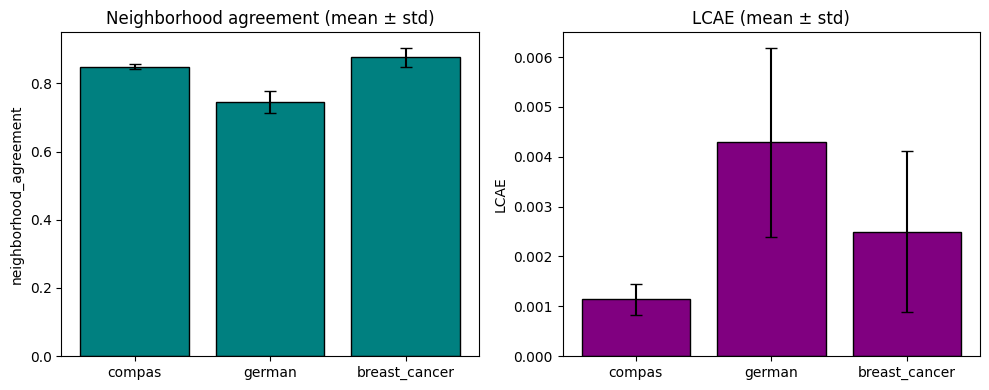

In [32]:
# neighborhood_agreement and LCAE (compact bar chart)
if "neighborhood_agreement_mean" in agg_df.columns and "lcae_mean" in agg_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    x = np.arange(len(agg_df))
    labels = agg_df["dataset"].values
    na_std = agg_df["neighborhood_agreement_std"] if "neighborhood_agreement_std" in agg_df.columns else 0
    axes[0].bar(x, agg_df["neighborhood_agreement_mean"], yerr=na_std,
                capsize=4, color="teal", edgecolor="black")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels)
    axes[0].set_ylabel("neighborhood_agreement")
    axes[0].set_title("Neighborhood agreement (mean ± std)")
    lcae_std = agg_df["lcae_std"] if "lcae_std" in agg_df.columns else 0
    axes[1].bar(x, agg_df["lcae_mean"], yerr=lcae_std,
                capsize=4, color="purple", edgecolor="black")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels)
    axes[1].set_ylabel("LCAE")
    axes[1].set_title("LCAE (mean ± std)")
    plt.tight_layout()
    plt.show()

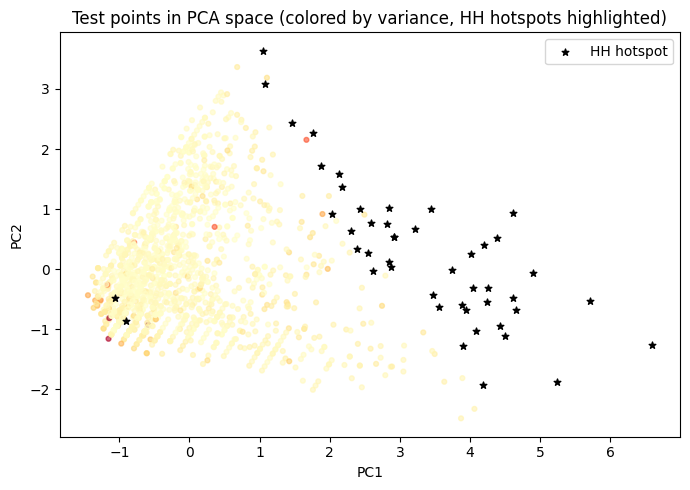

In [33]:
# PCA scatter: test points colored by variance, HH points highlighted (COMPAS seed=0)
X_test = get_transformed_test_features(run_dir, "compas")
spatial_res = run_spatial(run_dir, X_test, K=K, k=K_NN, seed=SEED)
HH_mask = spatial_res["HH_mask"]
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_test)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X_pca[~HH_mask, 0], X_pca[~HH_mask, 1], c=var_p[~HH_mask], cmap="YlOrRd", s=12, alpha=0.6)
ax.scatter(X_pca[HH_mask, 0], X_pca[HH_mask, 1], c="black", s=25, marker="*", label="HH hotspot", zorder=5)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Test points in PCA space (colored by variance, HH hotspots highlighted)")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Key takeaways

- **COMPAS:** Highest spatial clustering of multiplicity (Moran's I ~0.20, always significant).
  Mean variance low but spatially concentrated; HH hotspots consistently detected.
- **German Credit:** Highest mean variance and conflict; moderate Moran's I (~0.10).
- **Breast Cancer:** Highest accuracy (~0.97), lowest spatial structure (Moran's I ~0.03).
  Multiplicity is minimal and less spatially organized.

Overall: multiplicity is dataset-dependent and often spatially clustered, with COMPAS
exhibiting the strongest regional structure.

## 6. Optional lightweight export

Export summary tables for thesis inclusion.

In [34]:
# Optional: save thesis tables
THESIS_TABLES_DIR = RESULTS_DIR / "_thesis_tables"
THESIS_TABLES_DIR.mkdir(parents=True, exist_ok=True)

agg_df.to_csv(THESIS_TABLES_DIR / "dataset_summary.csv", index=False)
print(f"Saved: {THESIS_TABLES_DIR / 'dataset_summary.csv'}")

# Formatted table (mean ± std)
def fmt(mean_val, std_val, decimals=4):
    return f"{mean_val:.{decimals}f} ± {std_val:.{decimals}f}"

formatted = agg_df[["dataset", "n_runs"]].copy()
for m, s, label in [
    ("mean_variance_mean", "mean_variance_std", "mean_variance"),
    ("moran_i_mean", "moran_i_std", "moran_i"),
]:
    if m in agg_df.columns and s in agg_df.columns:
        formatted[label] = agg_df.apply(lambda r: fmt(r[m], r[s]), axis=1)
if "acc_mean_mean" in agg_df.columns:
    formatted["acc_mean"] = agg_df.apply(lambda r: fmt(r["acc_mean_mean"], r["acc_mean_std"]), axis=1)
    formatted["brier_mean"] = agg_df.apply(lambda r: fmt(r["brier_mean_mean"], r["brier_mean_std"]), axis=1)
    formatted["acc_ensemble"] = agg_df["acc_ensemble_mean"].apply(lambda x: f"{x:.4f}")
    formatted["brier_ensemble"] = agg_df["brier_ensemble_mean"].apply(lambda x: f"{x:.4f}")

formatted.to_csv(THESIS_TABLES_DIR / "dataset_summary_formatted.csv", index=False)
print(f"Saved: {THESIS_TABLES_DIR / 'dataset_summary_formatted.csv'}")
formatted

Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\results\_thesis_tables\dataset_summary.csv
Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\results\_thesis_tables\dataset_summary_formatted.csv


,dataset,n_runs,mean_variance,moran_i,acc_mean,brier_mean,acc_ensemble,brier_ensemble
0,compas,10,0.0013 ± 0.0003,0.1993 ± 0.0772,0.6796 ± 0.0080,0.2092 ± 0.0038,0.6821,0.2079
1,german,10,0.0050 ± 0.0021,0.1042 ± 0.0397,0.7491 ± 0.0276,0.1703 ± 0.0154,0.7570,0.1652
2,breast_cancer,10,0.0032 ± 0.0026,0.0315 ± 0.0207,0.9732 ± 0.0079,0.0218 ± 0.0065,0.9772,0.0186
